Running for n = 1000
Running for n = 2000
Running for n = 3000
Running for n = 4000
Running for n = 5000
Running for n = 6000
Running for n = 7000
Running for n = 8000
Running for n = 9000
Running for n = 10000
evaluate_n2 exceeded 60 seconds at n = 10000. Stopping.


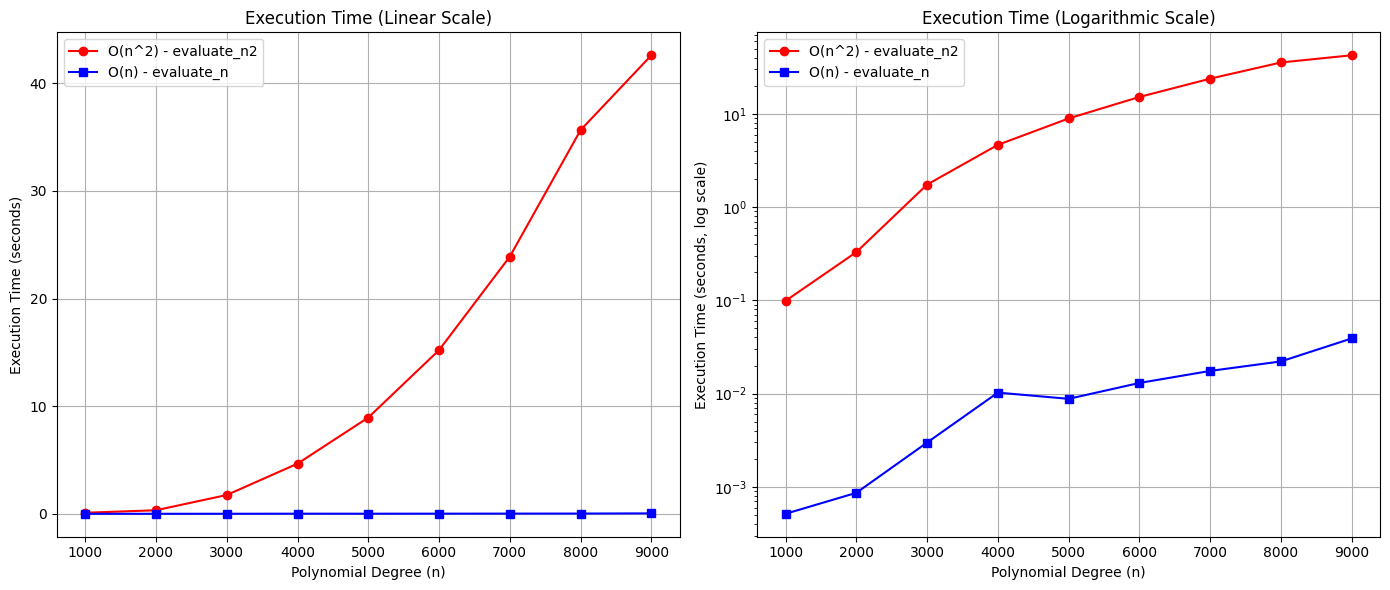

In [ ]:
import time
import random
import matplotlib.pyplot as plt

def evaluate_n2(A, x):
    """O(n^2) 시간 복잡도를 가지는 다항식 평가 함수"""
    n = len(A)
    result = 0
    for k in range(n):
        x_k = 1
        for _ in range(k):
            x_k *= x
        result += A[k] * x_k
    return result

def evaluate_n(A, x):
    """O(n) 시간 복잡도를 가지는 다항식 평가 함수 (Horner's Method 사용)"""
    n = len(A)
    result = 0
    for k in range(n-1, -1, -1):
        result = result * x + A[k]
    return result

# n값을 1000, 2000, 3000, ..., 10000, 20000, ... 증가시키기
n_values = []
times_n2 = []
times_n = []
n = 1000

while True:
    A = [random.randint(-1000, 1000) for _ in range(n)]
    x = random.randint(-1000, 1000)

    print(f"Running for n = {n}")

    # evaluate_n2 실행 시간 측정 (O(n^2))
    start_time = time.perf_counter()
    evaluate_n2(A, x)
    end_time = time.perf_counter()
    elapsed_time_n2 = end_time - start_time

    if elapsed_time_n2 > 60:
        print(f"evaluate_n2 exceeded 60 seconds at n = {n}. Stopping.")
        break

    # evaluate_n 실행 시간 측정 (O(n))
    start_time = time.perf_counter()
    evaluate_n(A, x)
    end_time = time.perf_counter()
    elapsed_time_n = end_time - start_time

    # 데이터 저장
    n_values.append(n)
    times_n2.append(elapsed_time_n2)
    times_n.append(elapsed_time_n)

    # n 증가 (1000, 2000, ..., 10000, 20000, ...)
    if n < 50000:
        n += 1000
    else:
        n += 10000

# 그래프 그리기 (일반 스케일 & 로그 스케일)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 일반 스케일 그래프
axes[0].plot(n_values, times_n2, label="O(n^2) - evaluate_n2", marker='o', linestyle='-', color='red')
axes[0].plot(n_values, times_n, label="O(n) - evaluate_n", marker='s', linestyle='-', color='blue')
axes[0].set_xlabel("Polynomial Degree (n)")
axes[0].set_ylabel("Execution Time (seconds)")
axes[0].set_title("Execution Time (Linear Scale)")
axes[0].legend()
axes[0].grid(True)

# 로그 스케일 그래프
axes[1].plot(n_values, times_n2, label="O(n^2) - evaluate_n2", marker='o', linestyle='-', color='red')
axes[1].plot(n_values, times_n, label="O(n) - evaluate_n", marker='s', linestyle='-', color='blue')
axes[1].set_xlabel("Polynomial Degree (n)")
axes[1].set_ylabel("Execution Time (seconds, log scale)")
axes[1].set_title("Execution Time (Logarithmic Scale)")
axes[1].set_yscale("log")  # 로그 스케일 적용
axes[1].legend()
axes[1].grid(True)

# 그래프 표시
plt.tight_layout()
plt.show()


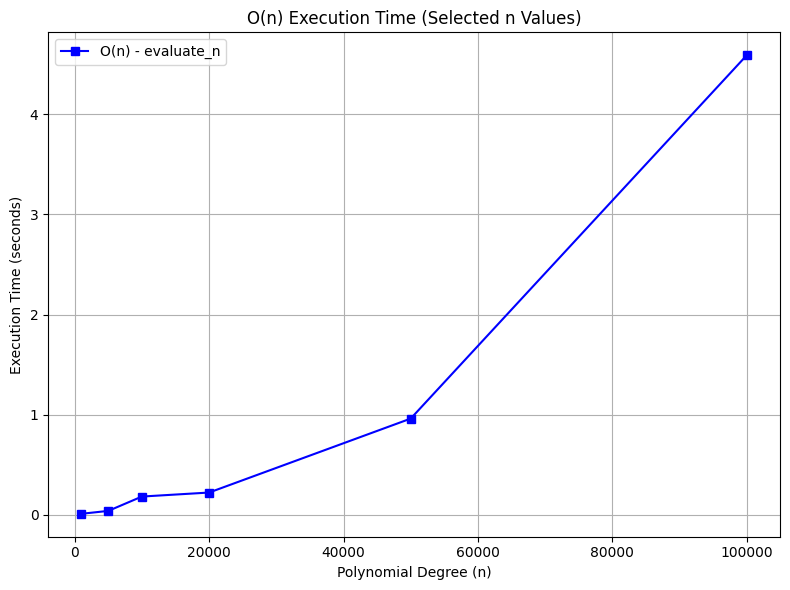

In [ ]:
import time
import random
import matplotlib.pyplot as plt

def evaluate_n(A, x):
    """O(n) 시간 복잡도를 가지는 다항식 평가 함수 (Horner's Method 사용)"""
    n = len(A)
    result = 0
    for k in range(n-1, -1, -1):
        result = result * x + A[k]
    return result

# n값을 1000부터 60초 넘기 전까지 증가, 오른쪽 그래프용 n은 지정된 값 사용
n_values_right = [1000, 5000, 10000, 20000, 50000, 100000]
times_n_right = []

# 첫 번째 그래프만 제거하고 두 번째 그래프만 그리기
for n in n_values_right:
    A = [random.randint(-1000, 1000) for _ in range(n)]
    x = random.randint(-1000, 1000)

    # evaluate_n 실행 시간 측정 (O(n))
    start_time = time.perf_counter()
    evaluate_n(A, x)
    end_time = time.perf_counter()
    elapsed_time_n = end_time - start_time

    times_n_right.append(elapsed_time_n)

# 오른쪽 그래프 그리기
plt.figure(figsize=(8, 6))

plt.plot(n_values_right, times_n_right, label="O(n) - evaluate_n", marker='s', linestyle='-', color='blue')
plt.xlabel("Polynomial Degree (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("O(n) Execution Time (Selected n Values)")
plt.legend()
plt.grid(True)

# 그래프 표시
plt.tight_layout()
plt.show()
